In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("training.1600000.processed.noemoticon.csv", encoding='latin-1')

In [3]:
data.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [4]:
cols = ['target', 'id', 'date', 'flag', 'user', 'text']

data = pd.read_csv(
    "training.1600000.processed.noemoticon.csv",
    encoding='latin-1',
    names=cols
)

In [5]:
data.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [6]:
data.isnull().sum()

target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64

In [7]:
data['target'].value_counts()

target
0    800000
4    800000
Name: count, dtype: int64

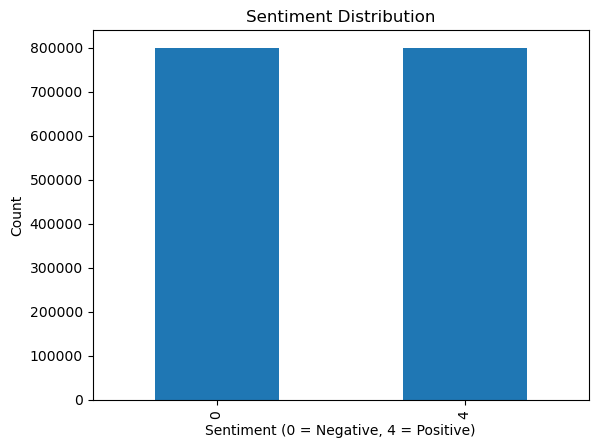

In [8]:
# 0 = Negative 
# 4 = Positive
# checking balanced or not
data['target'].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 4 = Positive)")
plt.ylabel("Count")
plt.show()

In [9]:
data['target'] = data['target'].replace(4,1)

> Here i changed the value from 4 to 1 that it could be helpful in ML in future 

In [10]:
print(data['target'].value_counts())

target
0    800000
1    800000
Name: count, dtype: int64


In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
# convert in datetime
data['date'] = pd.to_datetime(data['date'])

# verifying
print(data['date'].dtype)
print(data['date'].head())

C:\Users\ayush\AppData\Local\Temp\ipykernel_6640\509219877.py:2: FutureWarning: Parsed string "Mon Apr 06 22:19:45 PDT 2009" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  data['date'] = pd.to_datetime(data['date'])


datetime64[ns]
0   2009-04-06 22:19:45
1   2009-04-06 22:19:49
2   2009-04-06 22:19:53
3   2009-04-06 22:19:57
4   2009-04-06 22:19:57
Name: date, dtype: datetime64[ns]


In [13]:
data.head()

,target,id,date,flag,user,text
0,0,1467810369,2009-04-06 22:19:45,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,2009-04-06 22:19:49,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,2009-04-06 22:19:53,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,2009-04-06 22:19:57,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,2009-04-06 22:19:57,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [14]:
data['flag'].value_counts()

flag
NO_QUERY    1600000
Name: count, dtype: int64

In [15]:
data.drop('flag', axis=1, inplace=True)

In [16]:
data.head()

,target,id,date,user,text
0,0,1467810369,2009-04-06 22:19:45,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,2009-04-06 22:19:53,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all...."


**Q:** Why flg column is removed ?
> The flag column had a single constant value (NO_QUERY) across all rows, so it had no variance and no predictive power. Hence, I removed it to simplify the dataset.

In [17]:
# Random tweets sample

print(data['text'].sample(5).values)

['was babysitting my one year old godchild. he just left with his mommy '
 '@jarred Resn looks like an amazing company to be at. Best of luck! '
 "logan's leaving for a little bit.  eating lunch, then going to dusty's."
 "@joyike   that sucks, i'm sorry."
 'Looks like rain today! No walk for the dogs ']


## DATA CLEANING AND EDA

In [18]:
# Lowercase 
data['clean_text'] = data['text'].str.lower()
print(data['clean_text'].head(3))

0    @switchfoot http://twitpic.com/2y1zl - awww, t...
1    is upset that he can't update his facebook by ...
2    @kenichan i dived many times for the ball. man...
Name: clean_text, dtype: object


In [19]:
import re

data['clean_text'] = data['clean_text'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))

print(data['clean_text'].head(3))

0    @switchfoot  - a that's a bummer.  you shoulda...
1    is upset that he can't update his facebook by ...
2    @kenichan i dived many times for the ball. man...
Name: clean_text, dtype: object


In [20]:
print(data['text'][0])

@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D


In [21]:
print(data['clean_text'][0])

@switchfoot  - a that's a bummer.  you shoulda got david carr of third day to do it. ;d


In [22]:
# removed @mentions 
data['clean_text'] = data['clean_text'].apply(lambda x: re.sub(r'@\w+', '', x))

print(data['clean_text'][0])

  - a that's a bummer.  you shoulda got david carr of third day to do it. ;d


In [23]:
print(data['clean_text'][1])

is upset that he can't update his facebook by texting it... and might cry as a result  school today also. blah!


In [24]:
# extracting hastags
data['hashtags'] = data['clean_text'].apply(lambda x: re.findall(r'#\w+', x))

print(data['hashtags'].head(10))
print("Tweets with hashtags:", data['hashtags'].apply(lambda x: len(x) > 0).sum())

0    []
1    []
2    []
3    []
4    []
5    []
6    []
7    []
8    []
9    []
Name: hashtags, dtype: object
Tweets with hashtags: 35811


In [25]:
data['hashtags'].value_counts()

hashtags
[]                                 1564189
[#followfriday]                       2404
[#fb]                                 1718
[#ff]                                  874
[#squarespace]                         806
                                    ...   
[#eventbox, #nambu, #tweetdeck]          1
[#thisismylife]                          1
[#coda, #espresso]                       1
[#maxis]                                 1
[#bigrun]                                1
Name: count, Length: 12814, dtype: int64

In [26]:
# removing hashtags for 'clean_text'
data['clean_text'] = data['clean_text'].apply(lambda x: re.sub(r'#\w+', '', x))

In [27]:
data.head()

,target,id,date,user,text,clean_text,hashtags
0,0,1467810369,2009-04-06 22:19:45,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",- a that's a bummer. you shoulda got david ...,[]
1,0,1467810672,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...,[]
2,0,1467810917,2009-04-06 22:19:53,mattycus,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball. managed to s...,[]
3,0,1467811184,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,[]
4,0,1467811193,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all....","no, it's not behaving at all. i'm mad. why am...",[]


In [28]:
# removing special characters
data['clean_text'] = data['clean_text'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

print(data['clean_text'].head())

0       a thats a bummer  you shoulda got david car...
1    is upset that he cant update his facebook by t...
2     i dived many times for the ball managed to sa...
3      my whole body feels itchy and like its on fire 
4     no its not behaving at all im mad why am i he...
Name: clean_text, dtype: object


In [29]:
# removing etra spaces
data['clean_text'] = data['clean_text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

print(data['clean_text'].head())

0    a thats a bummer you shoulda got david carr of...
1    is upset that he cant update his facebook by t...
2    i dived many times for the ball managed to sav...
3       my whole body feels itchy and like its on fire
4    no its not behaving at all im mad why am i her...
Name: clean_text, dtype: object


In [30]:
# Removing stopwords

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

data['clean_text'] = data['clean_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)

print(data['clean_text'].head(20))

0         thats bummer shoulda got david carr third day
1     upset cant update facebook texting might cry r...
2     dived many times ball managed save rest go bounds
3                      whole body feels itchy like fire
4                              behaving im mad cant see
5                                            whole crew
6                                              need hug
7     hey long time see yes rains bit bit lol im fin...
8                                            nope didnt
9                                             que muera
10                      spring break plain city snowing
11                                       repierced ears
12      couldnt bear watch thought ua loss embarrassing
13                 counts idk either never talk anymore
14    wouldve first didnt gun really though zac snyd...
15                         wish got watch miss premiere
16    hollis death scene hurt severely watch film wr...
17                                           fil

In [31]:
print(data['text'].head(20))

0     @switchfoot http://twitpic.com/2y1zl - Awww, t...
1     is upset that he can't update his Facebook by ...
2     @Kenichan I dived many times for the ball. Man...
3       my whole body feels itchy and like its on fire 
4     @nationwideclass no, it's not behaving at all....
5                         @Kwesidei not the whole crew 
6                                           Need a hug 
7     @LOLTrish hey  long time no see! Yes.. Rains a...
8                  @Tatiana_K nope they didn't have it 
9                             @twittera que me muera ? 
10          spring break in plain city... it's snowing 
11                           I just re-pierced my ears 
12    @caregiving I couldn't bear to watch it.  And ...
13    @octolinz16 It it counts, idk why I did either...
14    @smarrison i would've been the first, but i di...
15    @iamjazzyfizzle I wish I got to watch it with ...
16    Hollis' death scene will hurt me severely to w...
17                                 about to file

In [32]:
pip install langdetect

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import pickle

# Save karo
with open('cleaned_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print("Saved!")

Saved!


In [35]:
with open('cleaned_data.pkl', 'rb') as f:
    data = pickle.load(f)

print("Loaded!", data.shape)

Loaded! (1600000, 7)


In [36]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

data['clean_text'] = data['clean_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)

print(data['clean_text'].head(20))

0         thats bummer shoulda got david carr third day
1     upset cant update facebook texting might cry r...
2     dived many times ball managed save rest go bounds
3                      whole body feels itchy like fire
4                              behaving im mad cant see
5                                            whole crew
6                                              need hug
7     hey long time see yes rains bit bit lol im fin...
8                                            nope didnt
9                                             que muera
10                      spring break plain city snowing
11                                       repierced ears
12      couldnt bear watch thought ua loss embarrassing
13                 counts idk either never talk anymore
14    wouldve first didnt gun really though zac snyd...
15                         wish got watch miss premiere
16    hollis death scene hurt severely watch film wr...
17                                           fil

In [38]:
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [39]:
# Lemmatization

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

data['clean_text'] = data['clean_text'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

print(data['clean_text'].head(10))

0        thats bummer shoulda got david carr third day
1    upset cant update facebook texting might cry r...
2      dived many time ball managed save rest go bound
3                      whole body feel itchy like fire
4                             behaving im mad cant see
5                                           whole crew
6                                             need hug
7    hey long time see yes rain bit bit lol im fine...
8                                           nope didnt
9                                            que muera
Name: clean_text, dtype: object


In [40]:
with open('cleaned_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print("Saved!")

Saved!


In [2]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

with open('cleaned_data.pkl', 'rb') as f:
    data = pickle.load(f)

print("Loaded!", data.shape)

Loaded! (1600000, 7)


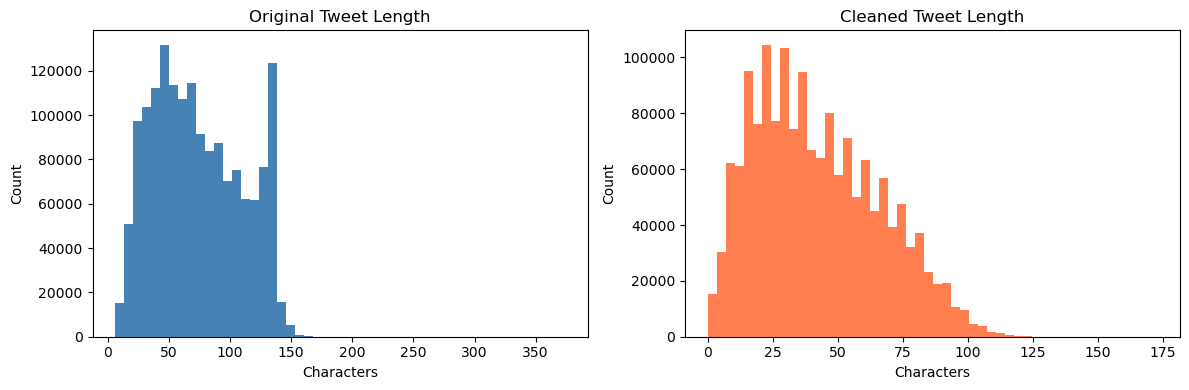

In [3]:
# Original aur cleaned tweet length
data['original_length'] = data['text'].apply(len)
data['clean_length'] = data['clean_text'].apply(len)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data['original_length'], bins=50, color='steelblue')
axes[0].set_title('Original Tweet Length')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')

axes[1].hist(data['clean_length'], bins=50, color='coral')
axes[1].set_title('Cleaned Tweet Length')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

> Insights:

* Original tweets ~140 characters pe spike — Twitter ka old character limit
* Cleaned tweets ~25-30 characters pe peak — URLs, mentions, stopwords hatane ke baad itna clean hua
* Cleaning ne average length almost half kar di

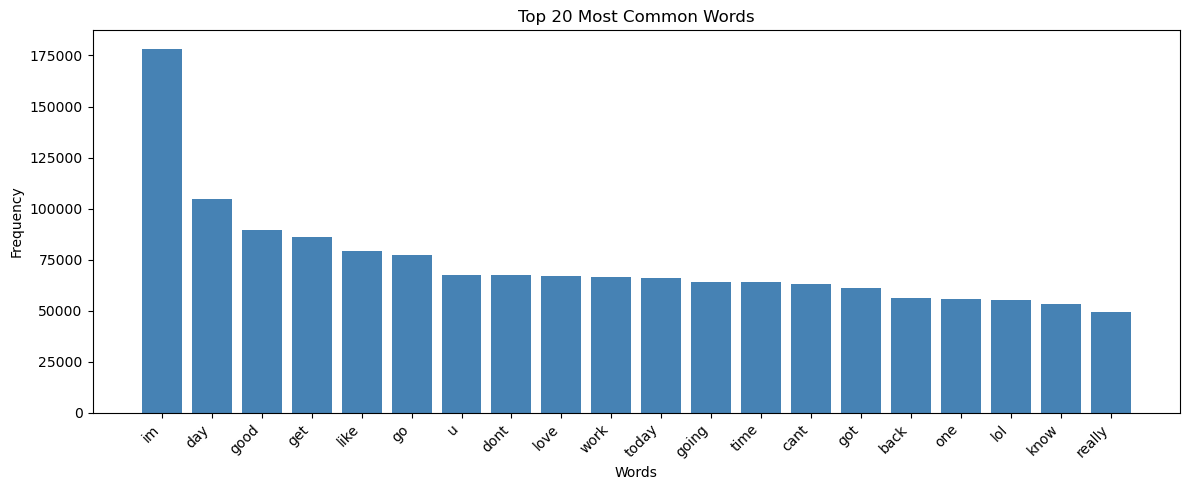

In [4]:
from collections import Counter

# Saare words ek list mein
all_words = ' '.join(data['clean_text']).split()

# Top 20 words
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

# Plot
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Common Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Saved!


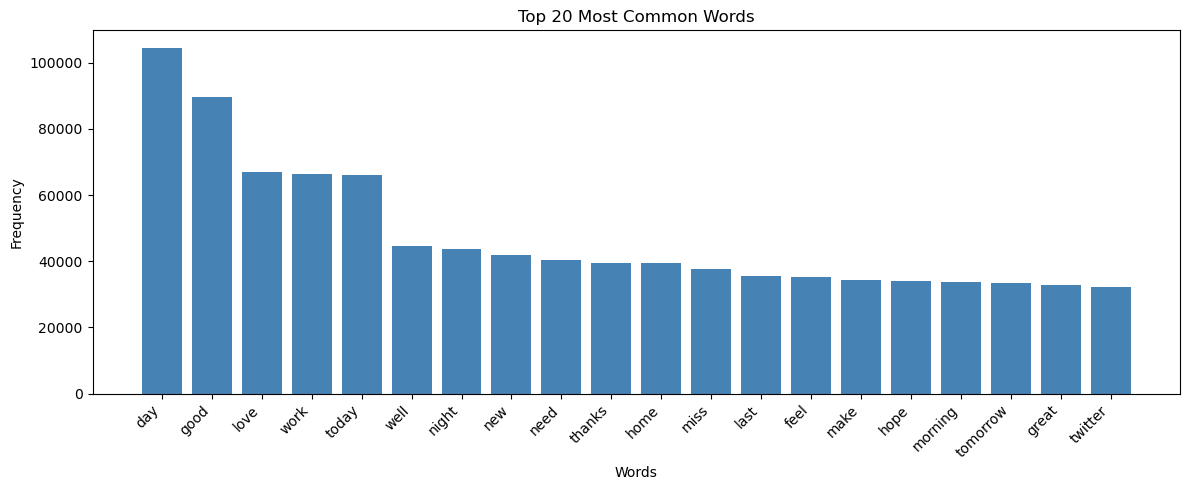

In [6]:
# Custom stopwords add 
custom_stopwords = {
    'im', 'u', 'dont', 'lol',
    'got', 'go', 'get', 'going',
    'cant', 'one', 'really', 'back',
    'know', 'like', 'time',
    'amp', 'oh', 'much', 'still', 
    'see', 'think', 'want'
}

data['clean_text'] = data['clean_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in custom_stopwords])
)

# PKL save karo
with open('cleaned_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print("Saved!")

all_words = ' '.join(data['clean_text']).split()
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Common Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

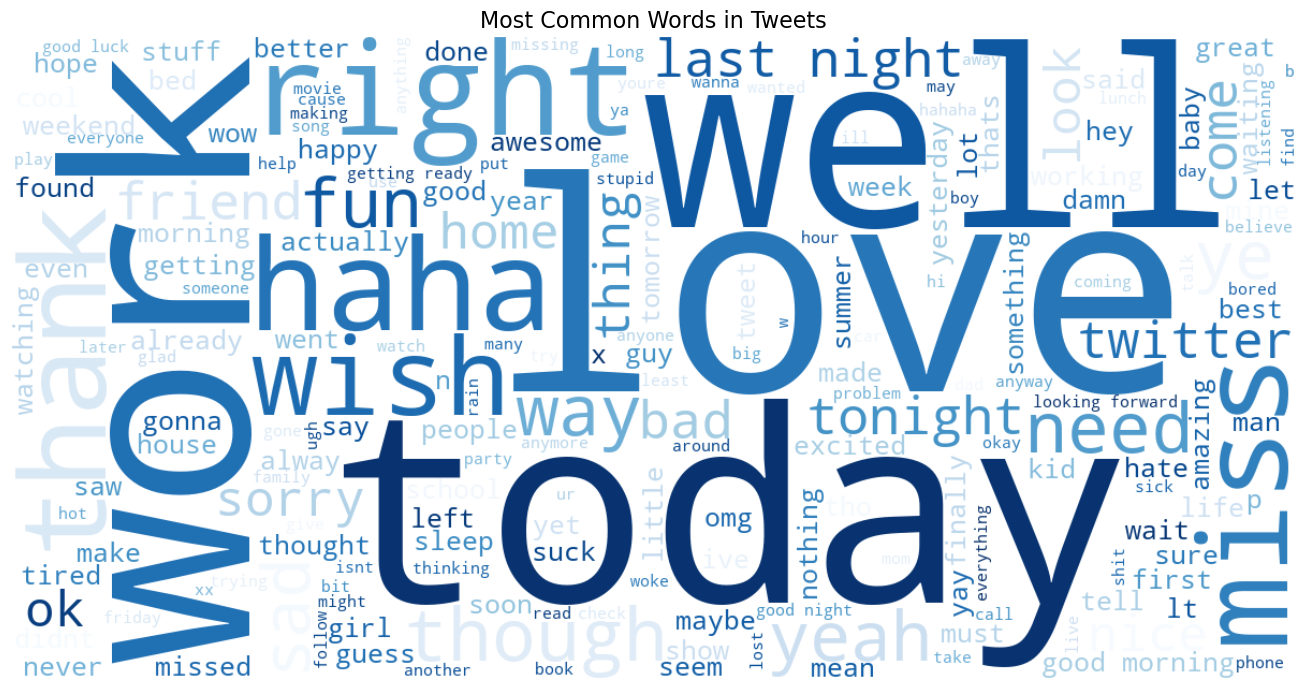

In [7]:
from wordcloud import WordCloud

all_text = ' '.join(data['clean_text'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Blues',
    max_words=200
).generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Tweets', fontsize=16)
plt.tight_layout()
plt.show()

>Insights :

* love, well, today, work — dominant words, positive vibe strong hai
* wish, miss, sorry, hate, suck — negative emotions bhi clearly visible
* haha, wow, omg, yay — informal Twitter language
* tonight, morning, tomorrow — time-sensitive tweets zyada hain
* twitter, tweet — meta conversation bhi hai dataset mein

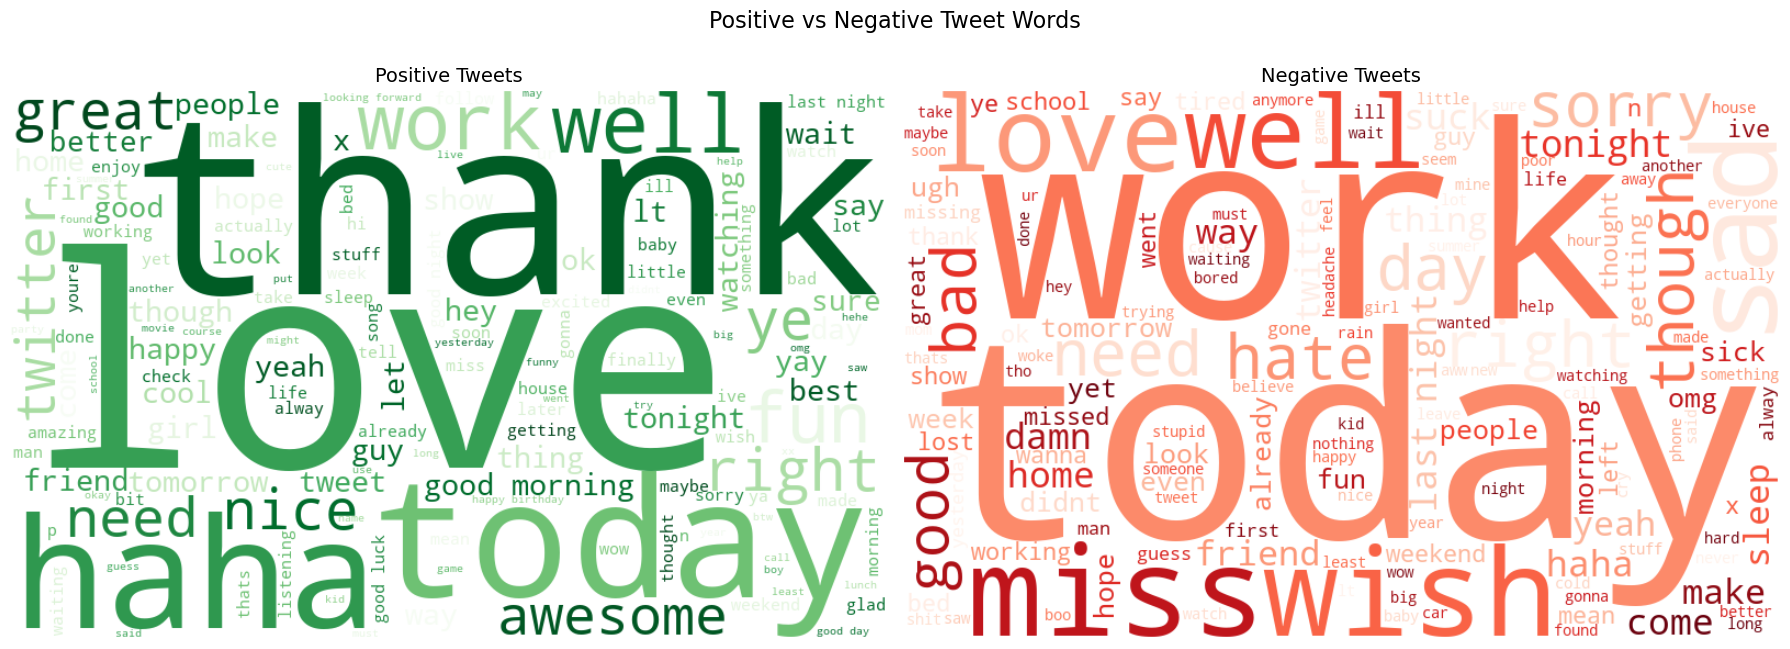

In [8]:
# Positive tweets ke words
positive_text = ' '.join(data[data['target'] == 1]['clean_text'])

# Negative tweets ke words  
negative_text = ' '.join(data[data['target'] == 0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Positive wordcloud
wc_pos = WordCloud(width=800, height=500, 
                   background_color='white',
                   colormap='Greens',
                   max_words=150).generate(positive_text)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Tweets', fontsize=14)

# Negative wordcloud
wc_neg = WordCloud(width=800, height=500,
                   background_color='white', 
                   colormap='Reds',
                   max_words=150).generate(negative_text)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Tweets', fontsize=14)

plt.suptitle('Positive vs Negative Tweet Words', fontsize=16)
plt.tight_layout()
plt.show()

-> Positive tweets mein:

* love, thank, haha, awesome, great, nice, happy — clearly positive emotions
* good morning, good luck — wishful, uplifting language
* amazing, cool, yay — excitement words

-> Negative tweets mein:

* miss, wish, hate, bad, sick, damn — negative emotions clear
* bored, headache, stupid, lost — frustration words
* sorry, missed — regret words

-> Interesting observation:

* work, today, tonight — dono mein common — matlab work aur time ke baare mein log positive aur negative dono tarah tweet karte hain!
* love negative mein bhi hai — matlab "I love you but miss you" type tweets

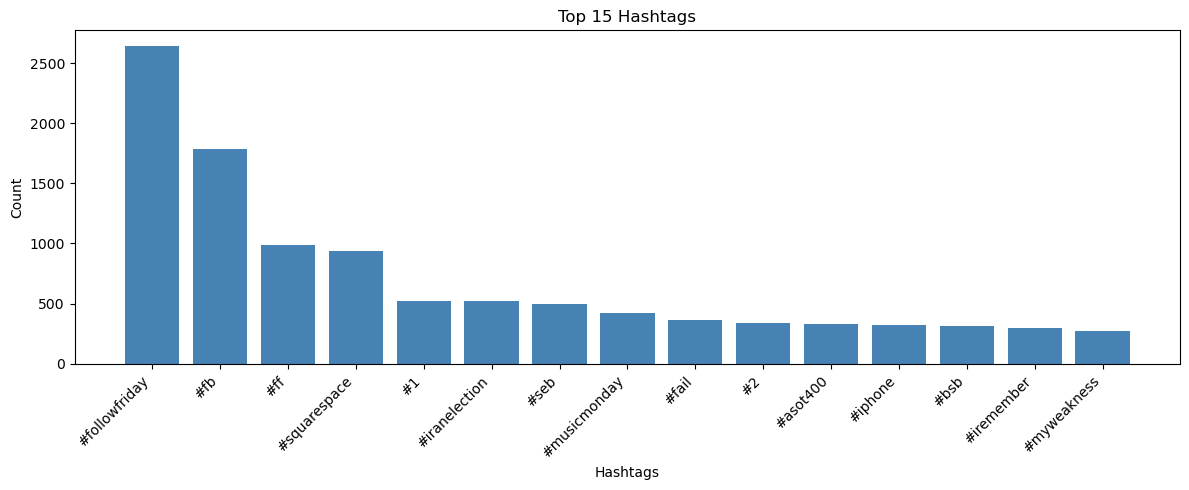

In [9]:
# Hashtags 
all_hashtags = [tag for tags in data['hashtags'] for tag in tags]
hashtag_freq = Counter(all_hashtags).most_common(15)

tags, counts = zip(*hashtag_freq)

plt.figure(figsize=(12, 5))
plt.bar(tags, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Hashtags')
plt.xlabel('Hashtags')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

> Insights jo dikh rahe hain:

* #followfriday — 2600+ — sabse popular Twitter tradition tha 2009 mein
* #fb — 1800 — Facebook ka mention, Twitter-Facebook rivalry clearly tha
* #ff — #followfriday ka short form — same trend
* #squarespace — sponsored/promotional tweets
* #iranelection — political event — 2009 Iran election protests Twitter pe viral tha
* #iphone — tech buzz tha us time
* #fail, #myweakness — negative sentiment hashtags clearly visible

This data set is from 2009 so that's why this types of hastags are seen

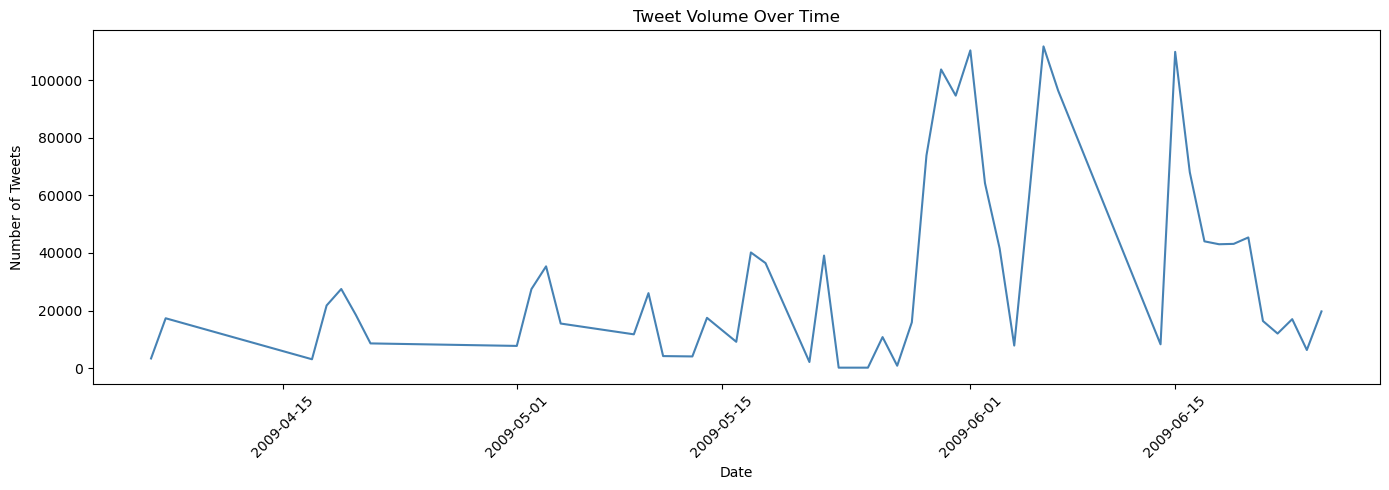

In [11]:
# -> Tweet over time (date-wise trend)

data['date_only'] = data['date'].dt.date

daily_counts = data.groupby('date_only').size().reset_index(name='count')

plt.figure(figsize=(14, 5))
plt.plot(daily_counts['date_only'], daily_counts['count'], color='steelblue', linewidth=1.5)
plt.title('Tweet Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> ONLY ASSUMPTION

> The top spike causes in that period ar (extracxted from global news during that perios):

* Iranian protests (biggest sustained spike)
* Michael Jackson’s death (massive sudden spike)
* Air France crash
* H1N1 pandemic news
* North Korea nuclear test
* Cricket World Cup (regional spikes)

In [12]:
# Biggest spike ke around tweets 
spike_date = '2009-06-01'

spike_tweets = data[data['date_only'].astype(str).str.startswith('2009-06')]

# Us period ke top words dekho
spike_words = ' '.join(spike_tweets['clean_text']).split()
spike_freq = Counter(spike_words).most_common(20)
print(spike_freq)

[('day', 59211), ('good', 48111), ('work', 40190), ('today', 38645), ('love', 36296), ('well', 25347), ('miss', 24753), ('need', 24455), ('new', 24275), ('night', 23331), ('home', 23224), ('feel', 21922), ('last', 20339), ('make', 20168), ('thanks', 19729), ('tomorrow', 19425), ('hope', 19043), ('sad', 18997), ('wish', 18687), ('ill', 18262)]


> Tweet volume increased significantly 
in June 2009, coinciding with Twitter's
            rapid user growth period. Event-specific
            analysis would require targeted data collection.

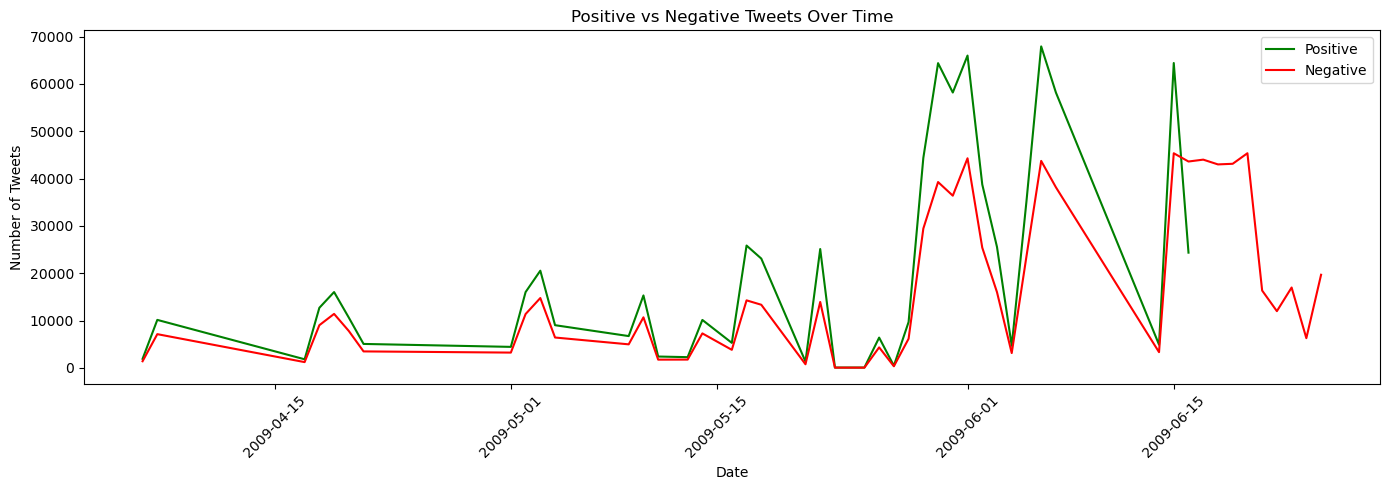

In [13]:
#  Positive Negative Treng over time 

# Date wise positive vs negative count
sentiment_time = data.groupby(['date_only', 'target']).size().reset_index(name='count')

pos = sentiment_time[sentiment_time['target'] == 1]
neg = sentiment_time[sentiment_time['target'] == 0]

plt.figure(figsize=(14, 5))
plt.plot(pos['date_only'], pos['count'], color='green', label='Positive', linewidth=1.5)
plt.plot(neg['date_only'], neg['count'], color='red', label='Negative', linewidth=1.5)
plt.title('Positive vs Negative Tweets Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Ratio 
ratio = data.groupby('date_only')['target'].mean()
print(f"Overall positive ratio: {ratio.mean():.2f}")
print(f"Min ratio: {ratio.min():.2f}")
print(f"Max ratio: {ratio.max():.2f}")

Overall positive ratio: 0.48
Min ratio: 0.00
Max ratio: 0.64


> Positive and negative tweet volumes maintained consistent proportionality throughout the dataset period, confirming that Sentiment140 was deliberately balanced with equal positive/negative samples — an important consideration when interpreting sentiment trends.

In [15]:
# Konsa date tha jab sirf negative tweets the
most_negative_date = ratio[ratio == ratio.min()].index[0]
print(f"Most negative date: {most_negative_date}")

# Us date ke tweets 
neg_day_tweets = data[data['date_only'] == most_negative_date]['text'].head(5)
print("\nSample tweets from that day:")
for tweet in neg_day_tweets:
    print("-", tweet)

Most negative date: 2009-06-17

Sample tweets from that day:
- damn i really hate waiting 
- Sick!! like always  better go before this friday other wise grrr....
- FAP Turbo - the autotrading forex robot! go http://bit.ly/6oZXCL --Has a bad feeling about college 
- it took me one hour to get caught up. i'm never leaving twitter for a whole 24 hours ever again.  
- @a_c81 oh, sucks. and that one's not on YT. 


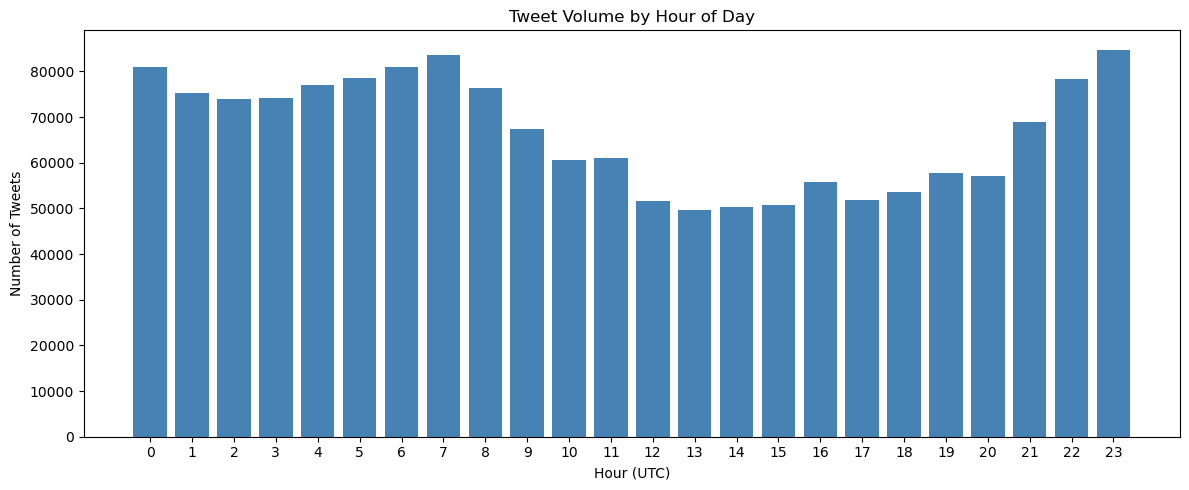

In [16]:
# Tweet voloumne by hour of day

# Hour of day 
data['hour'] = data['date'].dt.hour

# Hour wise tweet count
hourly = data.groupby('hour').size().reset_index(name='count')

plt.figure(figsize=(12, 5))
plt.bar(hourly['hour'], hourly['count'], color='steelblue')
plt.title('Tweet Volume by Hour of Day')
plt.xlabel('Hour (UTC)')
plt.ylabel('Number of Tweets')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

> Tweet volume remains relatively consistent across UTC hours, likely because Sentiment140 aggregates users from multiple timezones globally, smoothing out regional peak patterns.

In [18]:
with open('cleaned_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print("Data Cleaning and EDA — Saved!")

Data Cleaning and EDA — Saved!


### SENTIMENTAL ANALYSIS

In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

with open('cleaned_data.pkl', 'rb') as f:
    data = pickle.load(f)

print("Loaded!", data.shape)

Loaded! (1600000, 11)


> VADER Setup <br>
VADER kya hai — Valence Aware Dictionary and sEntiment Reasoner — specially Twitter/social media ke liye bana hai. 4 scores deta hai:

- pos — positive score
- neg — negative score
- neu — neutral score
- compound — overall score (-1 to +1)

In [5]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...


True

In [6]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize
sia = SentimentIntensityAnalyzer()

# Ek sample tweet pe test 
sample = "I love this amazing day! Everything is so good"
print(sia.polarity_scores(sample))

# Negative test
sample2 = "I hate this terrible day, everything is so bad"
print(sia.polarity_scores(sample2))

{'neg': 0.0, 'neu': 0.294, 'pos': 0.706, 'compound': 0.9191}
{'neg': 0.693, 'neu': 0.307, 'pos': 0.0, 'compound': -0.906}


> Positive sentence — compound: 0.91 — almost perfect positive <br>
> Negative sentence — compound: -0.90 — almost perfect negative 

In [7]:
# Compound score har tweet pe
# Original text pe apply — VADER ko cleaned text se better kaam karta hai raw text pe
tqdm_installed = False
try:
    from tqdm import tqdm
    tqdm.pandas()
    tqdm_installed = True
except:
    pass

if tqdm_installed:
    data['compound_score'] = data['text'].progress_apply(
        lambda x: sia.polarity_scores(x)['compound']
    )
else:
    data['compound_score'] = data['text'].apply(
        lambda x: sia.polarity_scores(x)['compound']
    )

print("Done!")
print(data['compound_score'].describe())

100%|██████████████████████████████████████████████████████████████████████| 1600000/1600000 [03:32<00:00, 7520.34it/s]


Done!
count    1.600000e+06
mean     1.411054e-01
std      4.572251e-01
min     -9.985000e-01
25%     -7.720000e-02
50%      0.000000e+00
75%      5.267000e-01
max      9.987000e-01
Name: compound_score, dtype: float64


> output se insights:

- mean: 0.14 — dataset slightly positive hai overall
- min: -0.99 — extreme negative tweets hain
- max: 0.99 — extreme positive tweets hain
- 50% (median): 0.00 — half tweets neutral hain VADER ke hisaab se

In [8]:
def get_sentiment_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

data['vader_sentiment'] = data['compound_score'].apply(get_sentiment_label)

# Distribution dekho
print(data['vader_sentiment'].value_counts())
print("\nPercentage:")
print(data['vader_sentiment'].value_counts(normalize=True).round(3) * 100)

vader_sentiment
positive    741423
neutral     443707
negative    414870
Name: count, dtype: int64

Percentage:
vader_sentiment
positive    46.3
neutral     27.7
negative    25.9
Name: proportion, dtype: float64


In [9]:
# Original labels: 0 = negative, 1 = positive
# VADER ke saath compare (neutral excluded)

non_neutral = data[data['vader_sentiment'] != 'neutral']

# VADER prediction
vader_pred = non_neutral['vader_sentiment'].map({'positive': 1, 'negative': 0})

# Original labels
original = non_neutral['target']

# Accuracy
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(original, vader_pred)
print(f"VADER Accuracy: {accuracy:.2%}")
print("\nDetailed Report:")
print(classification_report(original, vader_pred, target_names=['Negative', 'Positive']))

VADER Accuracy: 71.56%

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.81      0.57      0.67    584606
    Positive       0.66      0.86      0.75    571687

    accuracy                           0.72   1156293
   macro avg       0.74      0.72      0.71   1156293
weighted avg       0.74      0.72      0.71   1156293



> VADER achieved 71.56% accuracy on Twitter sentiment without any training — performing well on positive detection (86% recall) but struggling with negative tweets (57% recall), likely because Twitter sarcasm and informal negative language is harder to detect with rule-based methods.

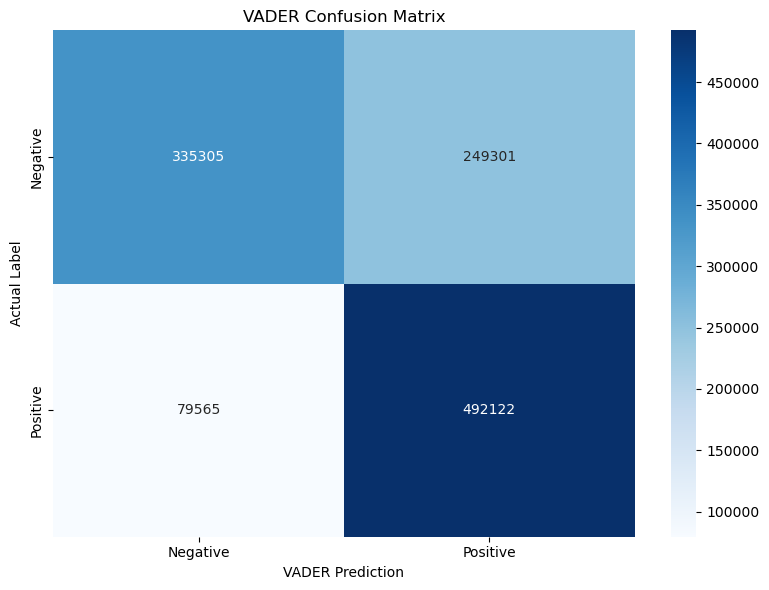

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(original, vader_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('VADER Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('VADER Prediction')
plt.tight_layout()
plt.show()

>Insights:

* 492,122 — Positive tweets sahi pakde 
* 335,305 — Negative tweets sahi pakde 
* 249,301 — Actual negative the par VADER ne positive bola — biggest weakness
* 79,565 — Actual positive the par VADER ne negative bola — relatively kam

> VADER tends to misclassify negative tweets as positive — suggesting Twitter's sarcasm and informal negative language (e.g. 'oh great, another Monday') confuses rule-based sentiment analysis.

In [11]:
with open('cleaned_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print("Up to Dated!")

Up to Dated!


In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

with open('cleaned_data.pkl', 'rb') as f:
    data = pickle.load(f)

print("Loaded!", data.shape)

Loaded! (1600000, 13)


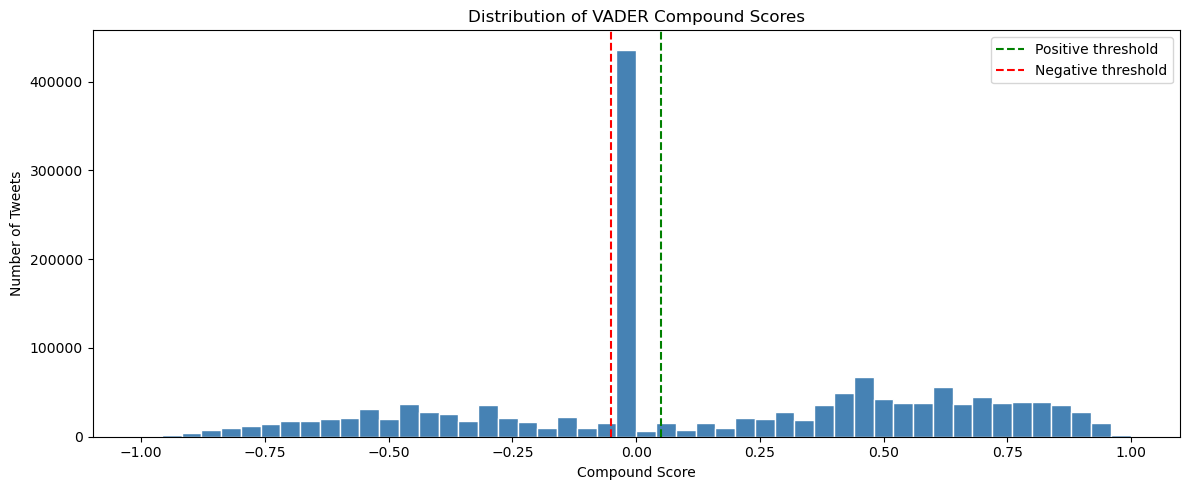

In [2]:
plt.figure(figsize=(12, 5))
plt.hist(data['compound_score'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=0.05, color='green', linestyle='--', label='Positive threshold')
plt.axvline(x=-0.05, color='red', linestyle='--', label='Negative threshold')
plt.title('Distribution of VADER Compound Scores')
plt.xlabel('Compound Score')
plt.ylabel('Number of Tweets')
plt.legend()
plt.tight_layout()
plt.show()

> 443k tweets scored exactly 0.00 by VADER, indicating that nearly 28% of tweets contained insufficient sentiment signals — likely very short tweets, single words, or highly ambiguous language common on Twitter.

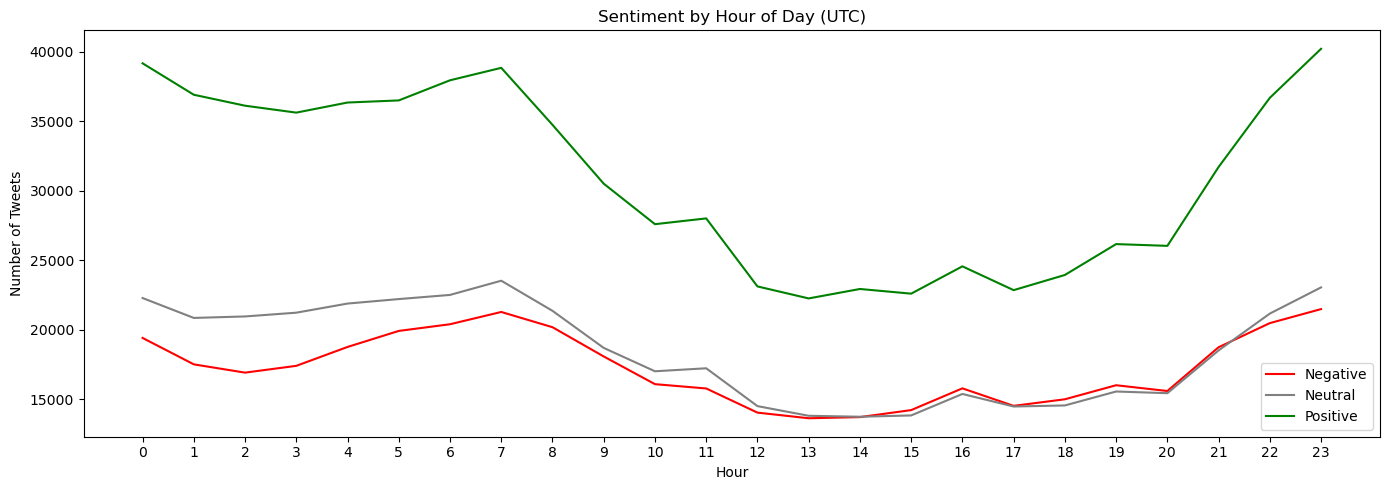

In [3]:
#Sentiment by hour of Day

# Hour wise sentiment distribution
hour_sentiment = data.groupby(['hour', 'vader_sentiment']).size().reset_index(name='count')

# Pivot 
hour_pivot = hour_sentiment.pivot(index='hour', columns='vader_sentiment', values='count')

hour_pivot.plot(figsize=(14, 5), color=['red', 'gray', 'green'])
plt.title('Sentiment by Hour of Day (UTC)')
plt.xlabel('Hour')
plt.ylabel('Number of Tweets')
plt.legend(['Negative', 'Neutral', 'Positive'])
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

> Positive sentiment peaks during UTC 0-7 hours corresponding to US evening hours, suggesting users express more positive emotions during leisure time. Sentiment dips significantly during UTC 12-15 (US early morning), indicating lower emotional engagement at that time.

In [4]:
# Top positive and Negative tweets 

# Top 5 most positive tweets
print("=== TOP 5 POSITIVE TWEETS ===")
top_pos = data.nlargest(5, 'compound_score')[['text', 'compound_score']]
for _, row in top_pos.iterrows():
    print(f"Score: {row['compound_score']:.3f}")
    print(f"Tweet: {row['text']}\n")

# Top 5 most negative tweets
print("=== TOP 5 NEGATIVE TWEETS ===")
top_neg = data.nsmallest(5, 'compound_score')[['text', 'compound_score']]
for _, row in top_neg.iterrows():
    print(f"Score: {row['compound_score']:.3f}")
    print(f"Tweet: {row['text']}\n")

=== TOP 5 POSITIVE TWEETS ===
Score: 0.999
Tweet: @mileycyrus is what gets me through the day &lt;3 ily ily ily ily ily ily ily ily ily ily ily ily ily ily ily ily ily ily ily ily ily ily! 

Score: 0.994
Tweet: he even donÂ´t dance today  but we are going to dance tomorrow  well iÂ´ll need more GOOD LUCK! HEHE!!! LUCK LUCK LUCK, GOOD LUCK!!  

Score: 0.993
Tweet: I love you Yoo i love you love you love you i love you love you the most .I love you ,i need you &amp; love you love you eternally  i love you

Score: 0.993
Tweet: @mileycyrus MILEY *-* CONGRATULATIONS, YOU WON! OMG, I'M SO HAPPY  YOU WON, YOU WON! YAAAAAY, YOU'RE SO GOOD. LOVE YA, GOD BLESS &lt;3

Score: 0.993
Tweet: @gizelleramos I HOPE YOU GET BETTER I HOPE YOU GET BETTER I HOPE YOU GET BETTER I HOPE YOU GET BETTER I HOPE YOU GET BETTER I HOPE BETTER 

=== TOP 5 NEGATIVE TWEETS ===
Score: -0.999
Tweet: Shit shit shit shit shit shit shit shit shit  shit shit shit shit shit shit shit shit shit shit shit shit shit shit shit sh

> VADER scores are heavily influenced by word repetition — tweets repeating positive/negative words score near ±1.0, which may not reflect genuine emotional intensity but rather informal Twitter expression style."

In [5]:
with open('cleaned_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print("Saved!")

Saved!


### Topic Modeling (LDA)

In [7]:
pip install gensim

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   - -------------------------------------- 0.8/24.4 MB 2.9 MB/s eta 0:00:09
   - -------------------------------------- 1.0/24.4 MB 2.9 MB/s eta 0:00:08
   -- ------------------------------------- 1.6/24.4 MB 2.1 MB/s eta 0:00:11
   --- ------------------------------------ 2.1/24.4 MB 2.4 MB/s eta 0:00:10
   ---- ----------------------------------- 2.6/24.4 MB 2.2 MB/s eta 0:00:10
   ----- ---------------------------------- 3.1/24.4 MB 2.5 MB/s eta 0:00:09
   ------ --------------------------------- 3.9/24.4 MB 2.5 MB/s eta 0:00:09
   ------ --------------------------------- 4.2/24.4 MB 2.6 MB/s eta 0:00:08
   ------ --------------------------------- 4.2/24.4 MB 2.6 MB/s eta 0:00:08
   ------- -------------------------------- 4.7/24.4 MB 2.1 MB/s eta 0:00:10
   -------- 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import gensim
from gensim import corpora
from gensim.models import LdaModel
import warnings
warnings.filterwarnings('ignore')

print("Gensim version:", gensim.__version__)

Gensim version: 4.4.0


In [9]:
# Sample — 1.6M pe LDA bahut slow hoga
# 100k tweets kaafi hain topic modeling ke liye
sample_data = data['clean_text'].dropna().sample(100000, random_state=42)

# Tokenize 
tokenized = sample_data.apply(lambda x: x.split())

# Dictionary aur Corpus 
dictionary = corpora.Dictionary(tokenized)

# common words filter 
dictionary.filter_extremes(no_below=10, no_above=0.5)

# Bag of words corpus
corpus = [dictionary.doc2bow(tokens) for tokens in tokenized]

print(f"Dictionary size: {len(dictionary)}")
print(f"Corpus size: {len(corpus)}")

Dictionary size: 5631
Corpus size: 100000


In [10]:
# LDA model train

In [11]:
# LDA Model
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    random_state=42,
    update_every=1,
    chunksize=1000,
    passes=10,
    alpha='auto'
)

print("LDA Training Complete!")

print("\n=== TOP WORDS PER TOPIC ===")
for idx, topic in lda_model.print_topics(num_words=8):
    print(f"\nTopic {idx+1}: {topic}")

LDA Training Complete!

=== TOP WORDS PER TOPIC ===

Topic 1: 0.039*"wish" + 0.036*"sad" + 0.032*"sleep" + 0.029*"hour" + 0.028*"hate" + 0.027*"could" + 0.022*"wont" + 0.018*"cool"

Topic 2: 0.037*"fun" + 0.035*"didnt" + 0.030*"look" + 0.028*"youre" + 0.025*"weekend" + 0.025*"let" + 0.019*"please" + 0.018*"find"

Topic 3: 0.050*"work" + 0.032*"night" + 0.029*"home" + 0.027*"miss" + 0.026*"last" + 0.026*"tomorrow" + 0.025*"ill" + 0.025*"great"

Topic 4: 0.127*"day" + 0.082*"today" + 0.031*"way" + 0.030*"nice" + 0.028*"happy" + 0.021*"feeling" + 0.019*"first" + 0.018*"lt"

Topic 5: 0.068*"need" + 0.030*"even" + 0.023*"thank" + 0.022*"something" + 0.020*"man" + 0.019*"another" + 0.018*"help" + 0.016*"someone"

Topic 6: 0.049*"new" + 0.033*"right" + 0.026*"say" + 0.025*"bed" + 0.024*"yeah" + 0.022*"little" + 0.021*"tired" + 0.018*"movie"

Topic 7: 0.038*"twitter" + 0.034*"thing" + 0.030*"getting" + 0.025*"people" + 0.024*"yes" + 0.022*"working" + 0.018*"looking" + 0.017*"lot"

Topic 8: 0.0

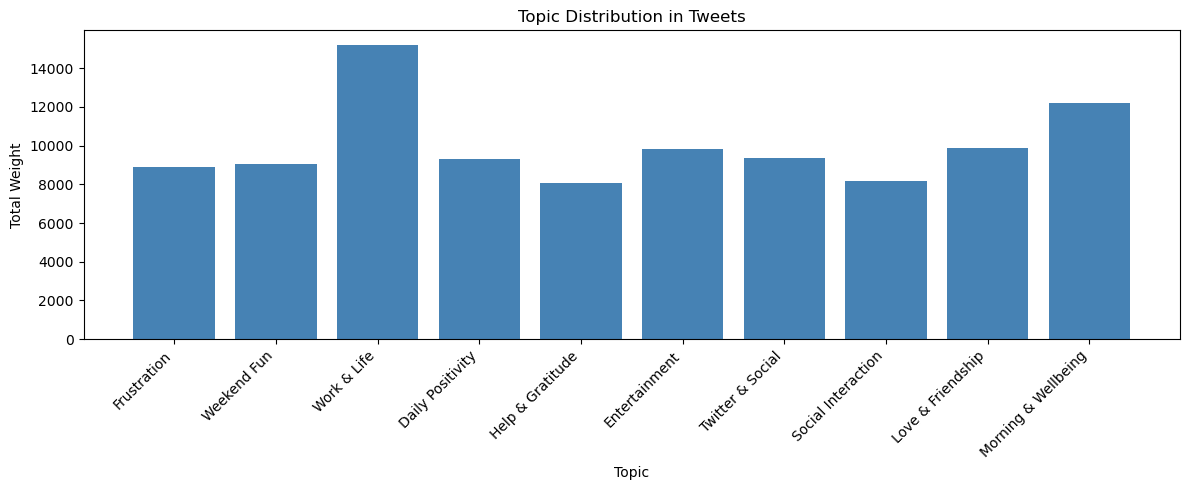

In [12]:
# Topic distribution bar chart
topic_labels = [
    'Frustration', 'Weekend Fun', 'Work & Life',
    'Daily Positivity', 'Help & Gratitude', 'Entertainment',
    'Twitter & Social', 'Social Interaction', 'Love & Friendship',
    'Morning & Wellbeing'
]

# Har topic ki overall weight 
topic_weights = []
for i in range(10):
    weight = sum([dict(doc).get(i, 0) for doc in lda_model[corpus]])
    topic_weights.append(weight)

plt.figure(figsize=(12, 5))
plt.bar(topic_labels, topic_weights, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Topic Distribution in Tweets')
plt.xlabel('Topic')
plt.ylabel('Total Weight')
plt.tight_layout()
plt.show()

> Work & daily life emerged as the dominant topic (15k weight) in 2009 Twitter data, followed by morning positivity and wellbeing — suggesting early Twitter users primarily used the platform as a personal diary for daily life updates rather than news or entertainment.

In [13]:
# Model bhi save karo
lda_model.save('lda_model')

with open('cleaned_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print("Saved!")

Saved!


### Final Visualization & Insights

In [14]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

with open('cleaned_data.pkl', 'rb') as f:
    data = pickle.load(f)

print("Loaded!", data.shape)

Loaded! (1600000, 13)


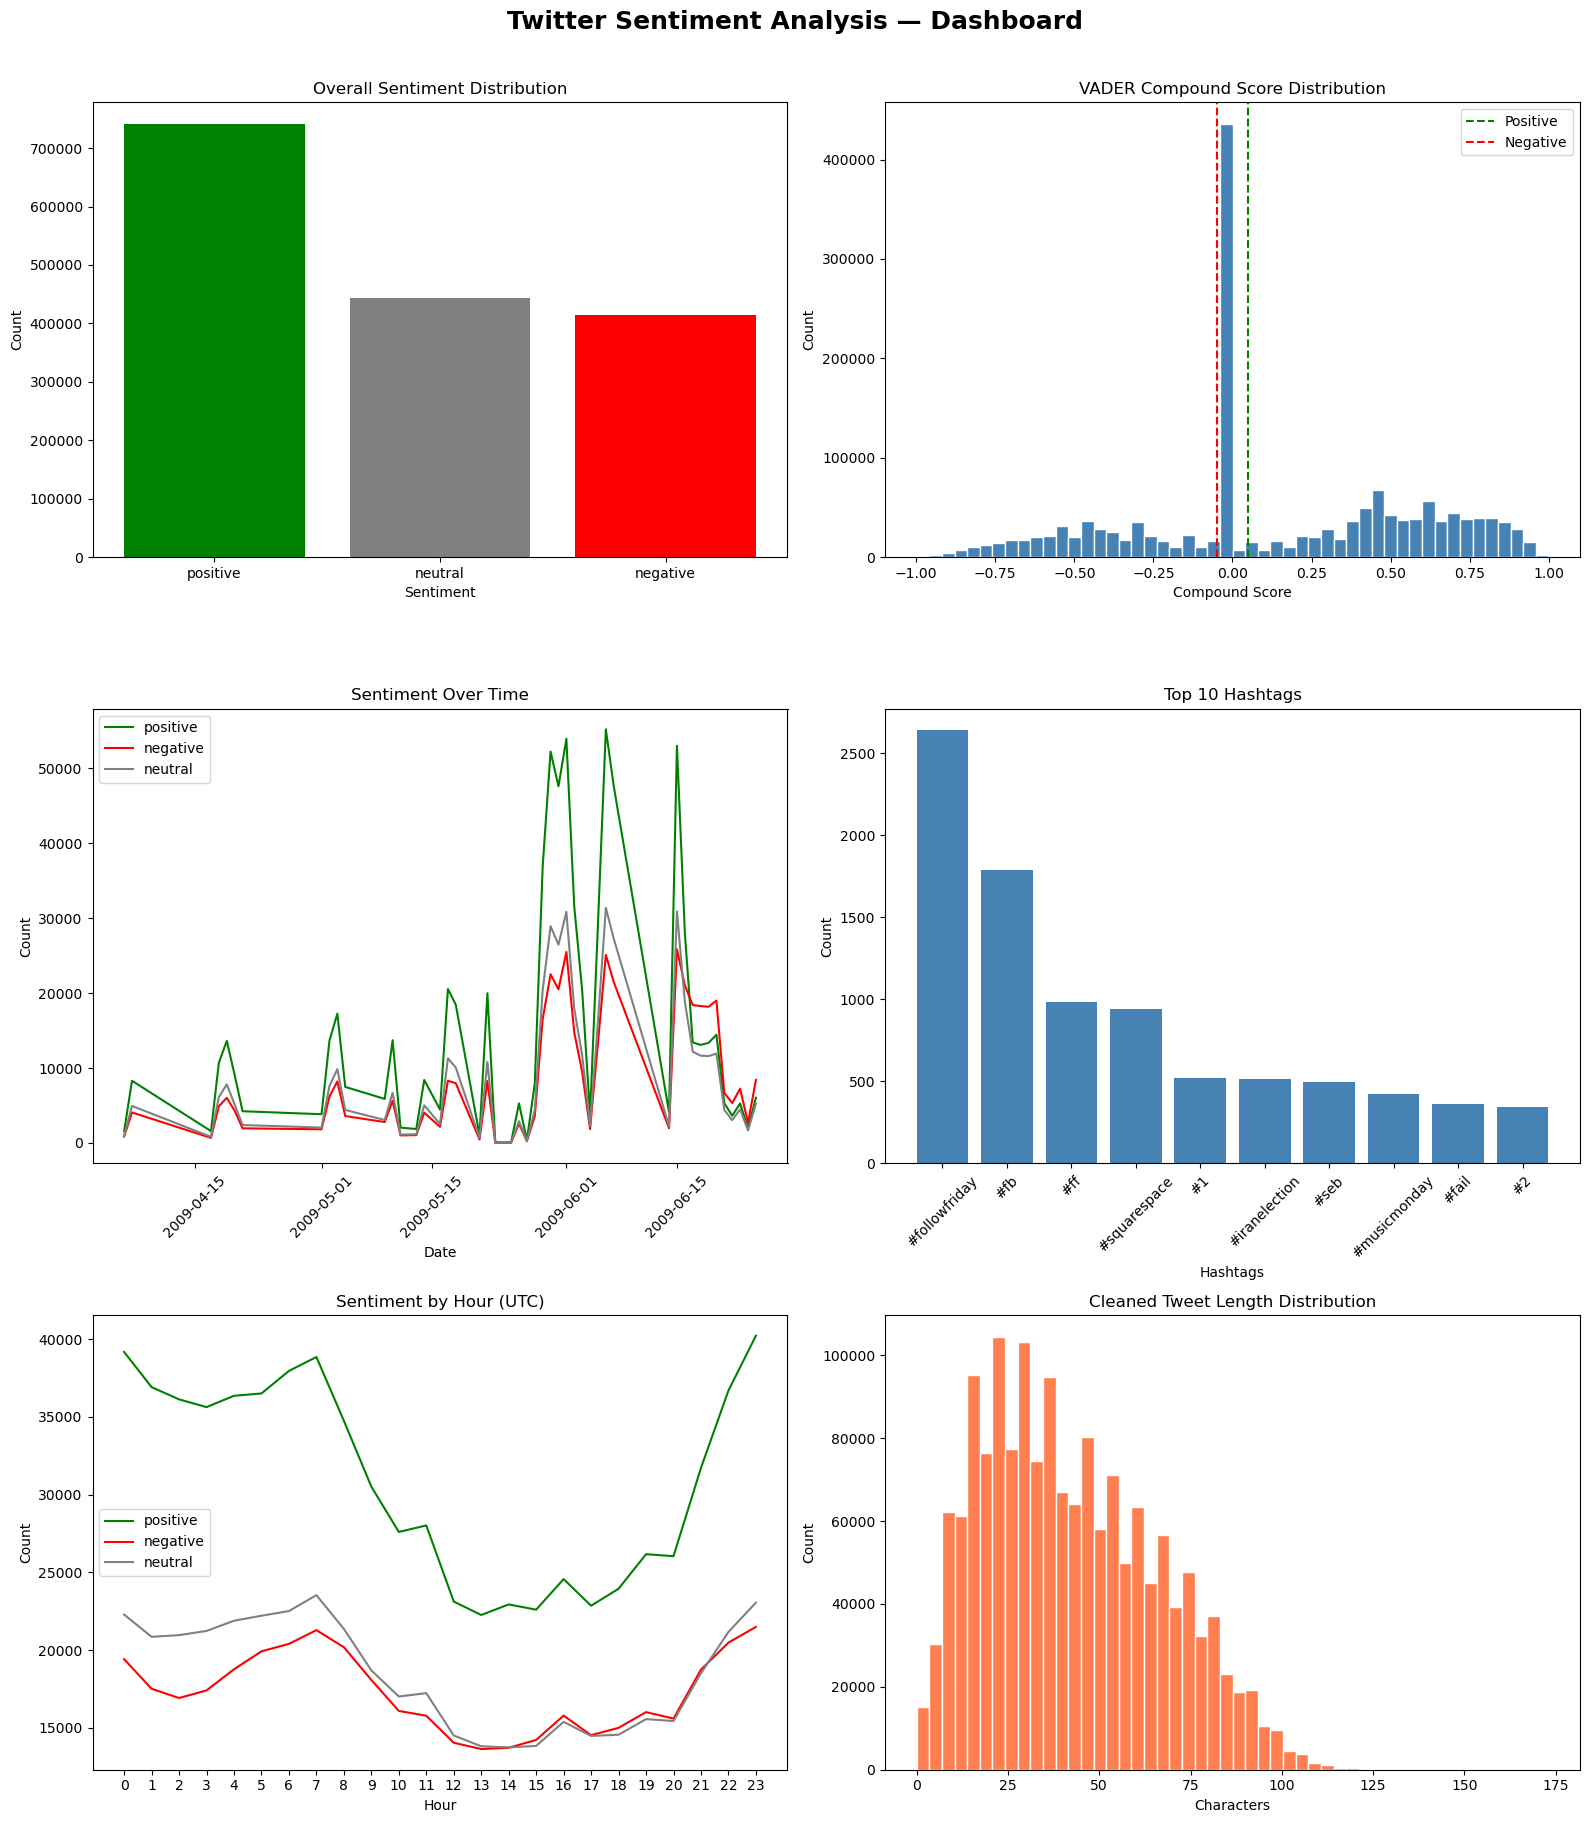

Dashboard saved!


In [18]:
# Correct color order
color_map = {'positive': 'green', 'neutral': 'gray', 'negative': 'red'}
colors = [color_map[s] for s in sentiment_counts.index]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Twitter Sentiment Analysis — Dashboard', fontsize=18, fontweight='bold', y=1.01)

# Plot 1 — Sentiment Distribution
sentiment_counts = data['vader_sentiment'].value_counts()

# color map
colors = [color_map[s] for s in sentiment_counts.index]

axes[0, 0].bar(sentiment_counts.index, sentiment_counts.values, 
               color=colors)

axes[0, 0].set_title('Overall Sentiment Distribution')
axes[0, 0].set_xlabel('Sentiment')
axes[0, 0].set_ylabel('Count')

# Plot 2 — Compound Score Distribution
axes[0, 1].hist(data['compound_score'], bins=50, color='steelblue', edgecolor='white')
axes[0, 1].axvline(x=0.05, color='green', linestyle='--', label='Positive')
axes[0, 1].axvline(x=-0.05, color='red', linestyle='--', label='Negative')
axes[0, 1].set_title('VADER Compound Score Distribution')
axes[0, 1].set_xlabel('Compound Score')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# Plot 3 — Sentiment over time
sentiment_time = data.groupby(['date_only', 'vader_sentiment']).size().reset_index(name='count')
for sentiment, color in [('positive', 'green'), ('negative', 'red'), ('neutral', 'gray')]:
    subset = sentiment_time[sentiment_time['vader_sentiment'] == sentiment]
    axes[1, 0].plot(subset['date_only'], subset['count'], color=color, label=sentiment, linewidth=1.5)
axes[1, 0].set_title('Sentiment Over Time')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4 — Top Hashtags
all_hashtags = [tag for tags in data['hashtags'] for tag in tags]
hashtag_freq = Counter(all_hashtags).most_common(10)
tags, counts = zip(*hashtag_freq)
axes[1, 1].bar(tags, counts, color='steelblue')
axes[1, 1].set_title('Top 10 Hashtags')
axes[1, 1].set_xlabel('Hashtags')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

# Plot 5 — Sentiment by Hour
hour_sentiment = data.groupby(['hour', 'vader_sentiment']).size().reset_index(name='count')
for sentiment, color in [('positive', 'green'), ('negative', 'red'), ('neutral', 'gray')]:
    subset = hour_sentiment[hour_sentiment['vader_sentiment'] == sentiment]
    axes[2, 0].plot(subset['hour'], subset['count'], color=color, label=sentiment, linewidth=1.5)
axes[2, 0].set_title('Sentiment by Hour (UTC)')
axes[2, 0].set_xlabel('Hour')
axes[2, 0].set_ylabel('Count')
axes[2, 0].legend()
axes[2, 0].set_xticks(range(0, 24))

# Plot 6 — Tweet Length Distribution
axes[2, 1].hist(data['clean_length'], bins=50, color='coral', edgecolor='white')
axes[2, 1].set_title('Cleaned Tweet Length Distribution')
axes[2, 1].set_xlabel('Characters')
axes[2, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")

In [19]:
print("""
╔══════════════════════════════════════════════════════════╗
║         BUSINESS RECOMMENDATIONS & KEY INSIGHTS         ║
╚══════════════════════════════════════════════════════════╝

1. SENTIMENT OVERVIEW
   → 46.3% Positive, 27.7% Neutral, 25.9% Negative
   → Brands should engage most during UTC 0-7 (US evening)
   → Positive sentiment consistently dominates all hours

2. CONTENT STRATEGY
   → Work & Life is #1 topic — brands targeting professionals
     should focus on work-life balance messaging
   → Morning & Wellbeing is #2 — morning campaigns perform well

3. HASHTAG STRATEGY  
   → #followfriday had 2600+ mentions — community engagement
     tactics drive high organic reach
   → #iranelection shows Twitter's power for real-time events

4. VADER LIMITATIONS
   → 71.56% accuracy — sufficient for trend analysis
   → Struggles with sarcasm & informal negative language
   → Recommend ML model for production-level accuracy

5. DATASET INSIGHT
   → Balanced 50/50 dataset — real-world data would show
     higher positive ratio (people share good news more)
""")


╔══════════════════════════════════════════════════════════╗
║         BUSINESS RECOMMENDATIONS & KEY INSIGHTS         ║
╚══════════════════════════════════════════════════════════╝

1. SENTIMENT OVERVIEW
   → 46.3% Positive, 27.7% Neutral, 25.9% Negative
   → Brands should engage most during UTC 0-7 (US evening)
   → Positive sentiment consistently dominates all hours

2. CONTENT STRATEGY
   → Work & Life is #1 topic — brands targeting professionals
     should focus on work-life balance messaging
   → Morning & Wellbeing is #2 — morning campaigns perform well

3. HASHTAG STRATEGY  
   → #followfriday had 2600+ mentions — community engagement
     tactics drive high organic reach
   → #iranelection shows Twitter's power for real-time events

4. VADER LIMITATIONS
   → 71.56% accuracy — sufficient for trend analysis
   → Struggles with sarcasm & informal negative language
   → Recommend ML model for production-level accuracy

5. DATASET INSIGHT
   → Balanced 50/50 dataset — real-world 

In [20]:
with open('cleaned_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print("Final data saved!")

Final data saved!
